# 📈 Tech Challenge — Fase 1 | Case Olist E-commerce
## Trilha 1: Crescimento e Receita
**Responsável:** Matheus

---

### Objetivo desta análise

Este notebook tem como foco extrair e apresentar, de forma clara e visual, os principais indicadores de
**crescimento e receita** do negócio a partir do *Brazilian E-Commerce Public Dataset by Olist*, cobrindo
pedidos realizados entre 2016 e 2018.

As análises aqui desenvolvidas respondem a três perguntas de negócio:

1. **Evolução mensal** de pedidos, receita e ticket médio — como o negócio está crescendo ao longo do tempo?
2. **Participação por categoria e por região (UF)** — quais categorias de produto e quais estados concentram
   mais receita?
3. **Top performers** — quais produtos e vendedores (*sellers*) mais se destacam em receita gerada?

> **Nota de governança:** todos os valores de receita consideram apenas o **preço do produto** (`price`),
> excluindo o valor do frete (`freight_value`), e apenas pedidos que **não foram cancelados**
> (`order_status != 'canceled'`), garantindo que a análise reflita vendas efetivamente realizadas.


## 1. Configuração inicial

Importação das bibliotecas utilizadas e configuração visual dos gráficos, adotando uma paleta consistente
e um estilo limpo, adequado para um relatório executivo.

In [1]:
# Bibliotecas de manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas de visualização
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Configuração visual padrão para todos os gráficos do notebook
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["font.size"] = 11

# Paleta de cores institucional (tons de azul/petróleo, alinhados à identidade Olist/POSTECH)
PALETTE = ["#0B3D91", "#1F77B4", "#4FA3D1", "#8DC3E3", "#B7D9EC", "#F2A900"]
sns.set_palette(PALETTE)

pd.options.display.float_format = "{:,.2f}".format

print("Bibliotecas carregadas e ambiente configurado com sucesso.")

Bibliotecas carregadas e ambiente configurado com sucesso.


## 2. Carga dos dados

Carregamos as tabelas do dataset Olist necessárias para a análise de **Crescimento e Receita**:

| Tabela | Uso nesta análise |
|---|---|
| `orders` | data da compra, status do pedido |
| `order_items` | preço, frete, produto e vendedor de cada item |
| `products` | categoria do produto |
| `customers` | estado (UF) do cliente |
| `sellers` | estado (UF) do vendedor |
| `product_category_name_translation` | tradução da categoria (pt → en) |


In [2]:
# Ajuste o caminho abaixo caso os arquivos estejam em outra pasta
DATA_PATH = "data/"

orders = pd.read_csv(DATA_PATH + "olist_orders_dataset.csv")
order_items = pd.read_csv(DATA_PATH + "olist_order_items_dataset.csv")
products = pd.read_csv(DATA_PATH + "olist_products_dataset.csv")
customers = pd.read_csv(DATA_PATH + "olist_customers_dataset.csv")
sellers = pd.read_csv(DATA_PATH + "olist_sellers_dataset.csv")
category_translation = pd.read_csv(DATA_PATH + "product_category_name_translation.csv")

print(f"orders:          {orders.shape}")
print(f"order_items:     {order_items.shape}")
print(f"products:        {products.shape}")
print(f"customers:       {customers.shape}")
print(f"sellers:         {sellers.shape}")
print(f"category_transl: {category_translation.shape}")

orders:          (99441, 8)
order_items:     (112650, 7)
products:        (32951, 9)
customers:       (99441, 5)
sellers:         (3095, 4)
category_transl: (71, 2)


## 3. Tratamento dos dados e construção da base analítica

Nesta etapa:

1. Convertemos a data de compra (`order_purchase_timestamp`) para o formato `datetime`.
2. Filtramos apenas pedidos **não cancelados**, garantindo que a receita reflita vendas válidas.
3. Unificamos (`merge`) as tabelas de pedidos, itens, produtos, clientes e vendedores em uma
   única base analítica (`df`), no nível de **item do pedido**.
4. Traduzimos e padronizamos o nome da categoria do produto.


In [3]:
# 3.1 Conversão de datas
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

# 3.2 Filtrando pedidos válidos (não cancelados)
status_removidos = ["canceled"]
orders_validos = orders[~orders["order_status"].isin(status_removidos)].copy()

print("Distribuição de status dos pedidos (base completa):")
print(orders["order_status"].value_counts())
print(f"\nPedidos válidos após filtro: {orders_validos.shape[0]:,} de {orders.shape[0]:,} "
      f"({orders_validos.shape[0] / orders.shape[0]:.1%})")

Distribuição de status dos pedidos (base completa):
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Pedidos válidos após filtro: 98,816 de 99,441 (99.4%)


In [4]:
# 3.3 Construção da base analítica unificada (nível: item do pedido)
df = (
    order_items
    .merge(orders_validos, on="order_id", how="inner")
    .merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
    .merge(category_translation, on="product_category_name", how="left")
    .merge(customers[["customer_id", "customer_state"]], on="customer_id", how="left")
    .merge(sellers[["seller_id", "seller_state"]], on="seller_id", how="left")
)

# 3.4 Padronização do nome da categoria (usa tradução em inglês; se ausente, mantém original)
df["categoria"] = df["product_category_name_english"].fillna(df["product_category_name"])
df["categoria"] = df["categoria"].fillna("categoria_nao_informada").str.replace("_", " ").str.title()

# 3.5 Coluna de mês de referência (para as séries temporais)
df["ano_mes"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)

print(f"Base analítica unificada: {df.shape[0]:,} linhas (itens de pedido) x {df.shape[1]} colunas")
df.head()

Base analítica unificada: 112,108 linhas (itens de pedido) x 20 colunas


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,product_category_name,product_category_name_english,customer_state,seller_state,categoria,ano_mes
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,cool_stuff,cool_stuff,RJ,SP,Cool Stuff,2017-09
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,pet_shop,pet_shop,SP,SP,Pet Shop,2017-04
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,moveis_decoracao,furniture_decor,MG,MG,Furniture Decor,2018-01
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,perfumaria,perfumery,SP,SP,Perfumery,2018-08
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,ferramentas_jardim,garden_tools,SP,PR,Garden Tools,2017-02


---
## 4. Evolução mensal de pedidos, receita e ticket médio

**Pergunta de negócio:** como o volume de pedidos, a receita e o valor médio gasto por pedido evoluíram
mês a mês entre 2016 e 2018?

- **Pedidos** = quantidade de pedidos únicos (`order_id`) no mês.
- **Receita** = soma do valor dos produtos (`price`) vendidos no mês.
- **Ticket médio** = receita do mês dividida pela quantidade de pedidos do mês.


In [5]:
# Agregação mensal
evolucao_mensal = (
    df.groupby("ano_mes")
      .agg(pedidos=("order_id", "nunique"), receita=("price", "sum"))
      .reset_index()
)
evolucao_mensal["ticket_medio"] = evolucao_mensal["receita"] / evolucao_mensal["pedidos"]
evolucao_mensal = evolucao_mensal.sort_values("ano_mes")

# Remove o último mês se estiver incompleto (poucos dias de dados), comum nesse dataset
print("Últimos meses disponíveis:")
evolucao_mensal.tail(5)

Últimos meses disponíveis:


,ano_mes,pedidos,receita,ticket_medio
19,2018-05,6833,"992,871.75",145.31
20,2018-06,6145,"863,265.53",140.48
21,2018-07,6233,"878,044.27",140.87
22,2018-08,6421,"848,860.10",132.20
23,2018-09,1,145.00,145.00


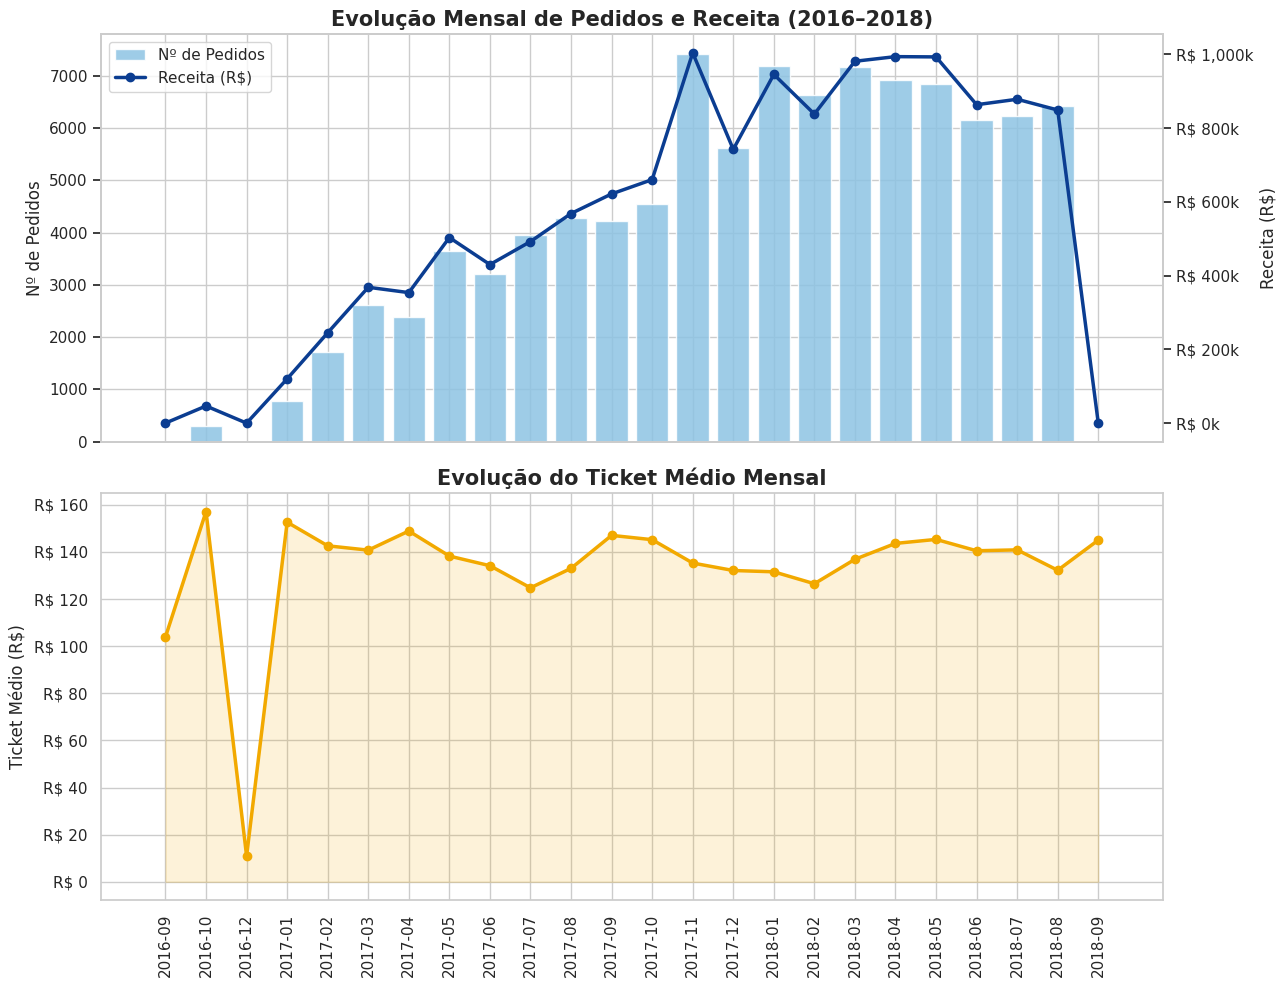

In [6]:
# Gráfico: Evolução mensal de Pedidos e Receita (eixos duplos) + Ticket Médio

fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

# --- Gráfico superior: Pedidos (barras) x Receita (linha) ---
ax1 = axes[0]
ax1.bar(evolucao_mensal["ano_mes"], evolucao_mensal["pedidos"],
        color=PALETTE[3], label="Nº de Pedidos", alpha=0.85)
ax1.set_ylabel("Nº de Pedidos")
ax1.set_title("Evolução Mensal de Pedidos e Receita (2016–2018)")

ax1b = ax1.twinx()
ax1b.plot(evolucao_mensal["ano_mes"], evolucao_mensal["receita"],
          color=PALETTE[0], marker="o", linewidth=2.5, label="Receita (R$)")
ax1b.set_ylabel("Receita (R$)")
ax1b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x/1000:,.0f}k"))
ax1b.grid(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines1b, labels1b = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines1b, labels1 + labels1b, loc="upper left")

# --- Gráfico inferior: Ticket médio ---
ax2 = axes[1]
ax2.plot(evolucao_mensal["ano_mes"], evolucao_mensal["ticket_medio"],
         color=PALETTE[5], marker="o", linewidth=2.5)
ax2.fill_between(evolucao_mensal["ano_mes"], evolucao_mensal["ticket_medio"],
                  alpha=0.15, color=PALETTE[5])
ax2.set_ylabel("Ticket Médio (R$)")
ax2.set_title("Evolução do Ticket Médio Mensal")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))

for ax in axes:
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

**Leitura executiva:** o gráfico permite identificar a trajetória de crescimento do volume de pedidos e
da receita ao longo do período, bem como se o ticket médio se manteve estável, cresceu ou caiu — um sinal
importante sobre a estratégia comercial (crescimento por volume vs. crescimento por valor agregado).

---
## 5. Participação por categoria e por região (UF)

**Pergunta de negócio:** quais categorias de produto e quais estados (UF) concentram a maior parte da
receita do negócio?

### 5.1 Participação por categoria de produto (Top 10)


In [7]:
receita_categoria = (
    df.groupby("categoria")["price"]
      .sum()
      .sort_values(ascending=False)
      .reset_index(name="receita")
)
receita_categoria["participacao_%"] = 100 * receita_categoria["receita"] / receita_categoria["receita"].sum()

top10_categorias = receita_categoria.head(10)
top10_categorias

,categoria,receita,participacao_%
0,Health Beauty,"1,255,695.13",9.30
1,Watches Gifts,"1,198,185.21",8.88
2,Bed Bath Table,"1,035,964.06",7.68
3,Sports Leisure,"979,740.92",7.26
4,Computers Accessories,"904,322.02",6.70
5,Furniture Decor,"727,465.05",5.39
6,Housewares,"626,825.80",4.64
7,Cool Stuff,"620,835.39",4.60
8,Auto,"586,620.73",4.35
9,Garden Tools,"481,009.94",3.56


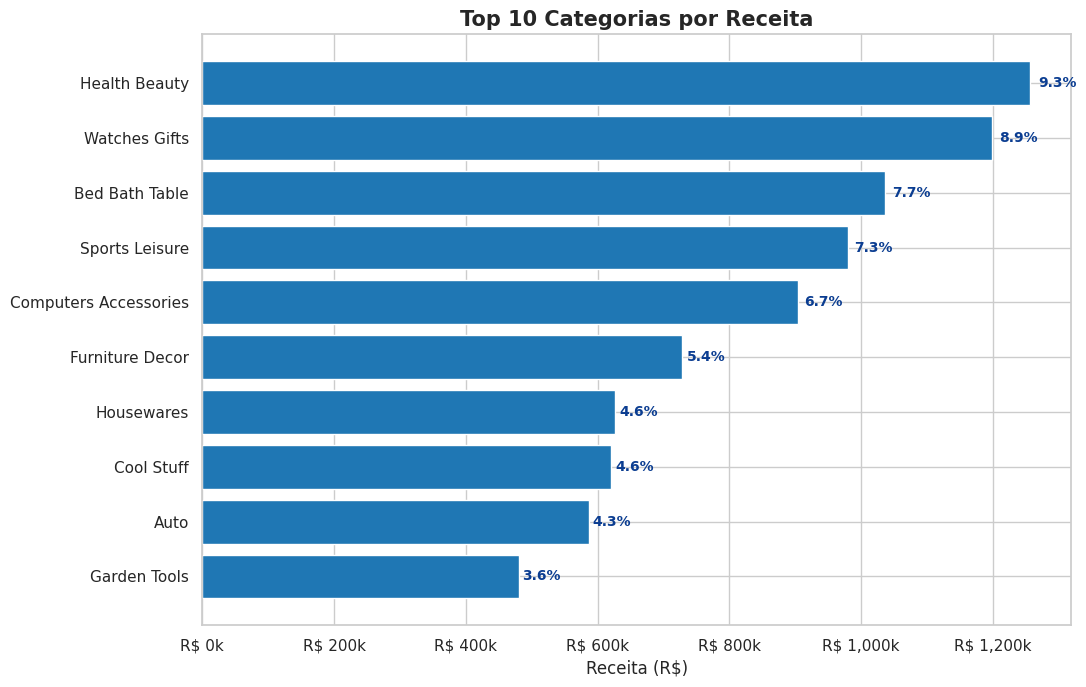

As 10 categorias acima concentram 62.4% da receita total.


In [8]:
fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(top10_categorias["categoria"][::-1], top10_categorias["receita"][::-1],
               color=PALETTE[1])
ax.set_xlabel("Receita (R$)")
ax.set_title("Top 10 Categorias por Receita")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x/1000:,.0f}k"))

# Rótulos com % de participação
for bar, pct in zip(bars, top10_categorias["participacao_%"][::-1]):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
            f"{pct:.1f}%", va="center", fontsize=10, color=PALETTE[0], fontweight="bold")

plt.tight_layout()
plt.show()

print(f"As 10 categorias acima concentram {top10_categorias['participacao_%'].sum():.1f}% da receita total.")

### 5.2 Participação por região (UF do cliente)

In [9]:
receita_uf = (
    df.groupby("customer_state")["price"]
      .sum()
      .sort_values(ascending=False)
      .reset_index(name="receita")
)
receita_uf["participacao_%"] = 100 * receita_uf["receita"] / receita_uf["receita"].sum()
receita_uf

,customer_state,receita,participacao_%
0,SP,"5,165,166.12",38.27
1,RJ,"1,811,923.32",13.43
2,MG,"1,573,667.19",11.66
3,RS,"742,809.68",5.50
4,PR,"676,883.06",5.02
5,SC,"518,578.28",3.84
6,BA,"507,108.83",3.76
7,DF,"300,886.45",2.23
8,GO,"287,870.46",2.13
9,ES,"273,532.13",2.03


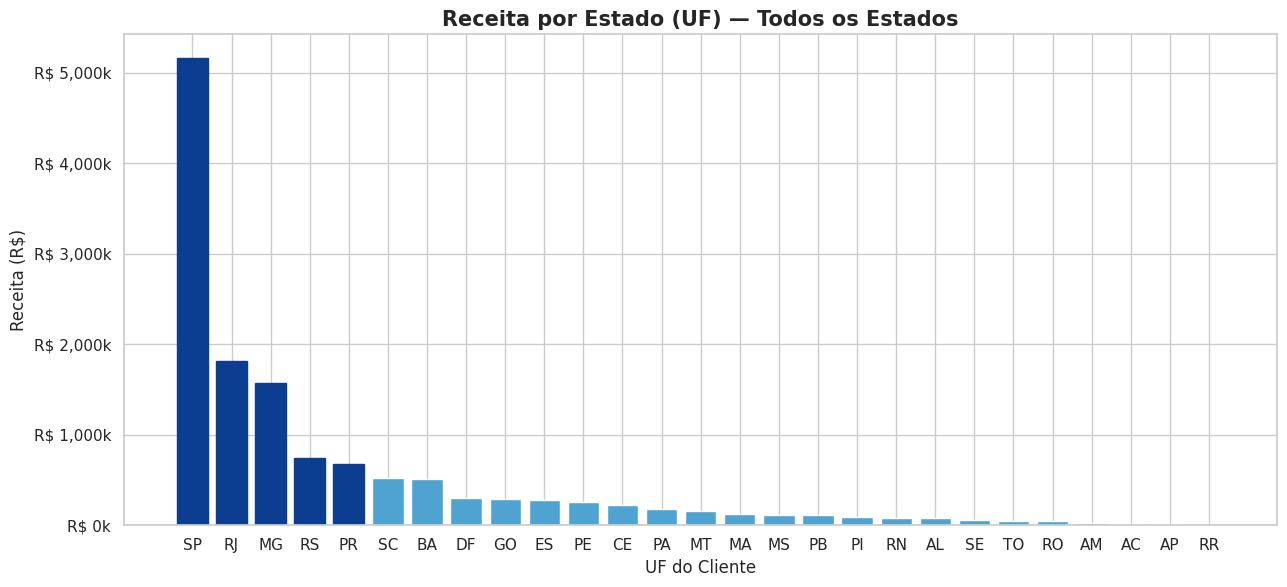

Top 5 estados concentram 73.9% da receita total:
customer_state      receita  participacao_%
            SP 5,165,166.12           38.27
            RJ 1,811,923.32           13.43
            MG 1,573,667.19           11.66
            RS   742,809.68            5.50
            PR   676,883.06            5.02


In [10]:
fig, ax = plt.subplots(figsize=(13, 6))

bars = ax.bar(receita_uf["customer_state"], receita_uf["receita"], color=PALETTE[2])
ax.set_ylabel("Receita (R$)")
ax.set_xlabel("UF do Cliente")
ax.set_title("Receita por Estado (UF) — Todos os Estados")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x/1000:,.0f}k"))

# Destaca o Top 5 estados em cor diferente
top5_ufs = set(receita_uf.head(5)["customer_state"])
for bar, uf in zip(bars, receita_uf["customer_state"]):
    if uf in top5_ufs:
        bar.set_color(PALETTE[0])

plt.tight_layout()
plt.show()

top5 = receita_uf.head(5)
print(f"Top 5 estados concentram {top5['participacao_%'].sum():.1f}% da receita total:")
print(top5.to_string(index=False))

**Leitura executiva:** a concentração de receita em poucas categorias e estados indica onde estão as
maiores oportunidades de investimento em marketing, estoque e logística, mas também sinaliza risco de
dependência — um ponto relevante para a estratégia de diversificação regional e de portfólio.

---
## 6. Identificação de produtos e sellers top performers

**Pergunta de negócio:** quais produtos e quais vendedores (*sellers*) mais geram receita para o negócio?


In [11]:
top_produtos = (
    df.groupby("product_id")
      .agg(receita=("price", "sum"), unidades_vendidas=("order_item_id", "count"),
           categoria=("categoria", "first"))
      .sort_values("receita", ascending=False)
      .head(10)
      .reset_index()
)
top_produtos["product_id_curto"] = top_produtos["product_id"].str[:8] + "…"
top_produtos

,product_id,receita,unidades_vendidas,categoria,product_id_curto
0,bb50f2e236e5eea0100680137654686c,"63,885.00",195,Health Beauty,bb50f2e2…
1,6cdd53843498f92890544667809f1595,"54,730.20",156,Health Beauty,6cdd5384…
2,d6160fb7873f184099d9bc95e30376af,"48,899.34",35,Computers,d6160fb7…
3,d1c427060a0f73f6b889a5c7c61f2ac4,"46,916.51",341,Computers Accessories,d1c42706…
4,99a4788cb24856965c36a24e339b6058,"42,938.66",487,Bed Bath Table,99a4788c…
5,3dd2a17168ec895c781a9191c1e95ad7,"41,082.60",274,Computers Accessories,3dd2a171…
6,25c38557cf793876c5abdd5931f922db,"38,907.32",38,Baby,25c38557…
7,5f504b3a1c75b73d6151be81eb05bdc9,"37,733.90",63,Cool Stuff,5f504b3a…
8,53b36df67ebb7c41585e8d54d6772e08,"37,683.42",323,Watches Gifts,53b36df6…
9,aca2eb7d00ea1a7b8ebd4e68314663af,"37,608.90",527,Furniture Decor,aca2eb7d…


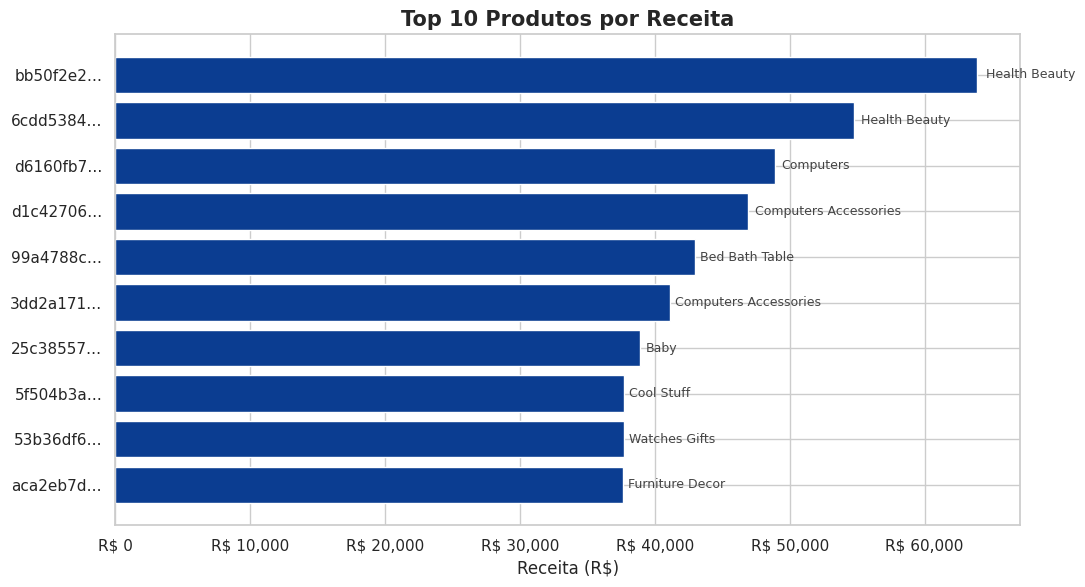

In [12]:
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(top_produtos["product_id_curto"][::-1], top_produtos["receita"][::-1],
               color=PALETTE[0])
ax.set_xlabel("Receita (R$)")
ax.set_title("Top 10 Produtos por Receita")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))

for bar, cat in zip(bars, top_produtos["categoria"][::-1]):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
            cat, va="center", fontsize=9, color="#444444")

plt.tight_layout()
plt.show()

In [13]:
top_sellers = (
    df.groupby("seller_id")
      .agg(receita=("price", "sum"), pedidos=("order_id", "nunique"),
           uf=("seller_state", "first"))
      .sort_values("receita", ascending=False)
      .head(10)
      .reset_index()
)
top_sellers["seller_id_curto"] = top_sellers["seller_id"].str[:8] + "…"
top_sellers["ticket_medio"] = top_sellers["receita"] / top_sellers["pedidos"]
top_sellers

,seller_id,receita,pedidos,uf,seller_id_curto,ticket_medio
0,4869f7a5dfa277a7dca6462dcf3b52b2,"229,237.63",1131,SP,4869f7a5…,202.69
1,53243585a1d6dc2643021fd1853d8905,"222,776.05",358,BA,53243585…,622.28
2,4a3ca9315b744ce9f8e9374361493884,"200,326.12",1804,SP,4a3ca931…,111.05
3,fa1c13f2614d7b5c4749cbc52fecda94,"192,842.13",584,SP,fa1c13f2…,330.21
4,7c67e1448b00f6e969d365cea6b010ab,"187,923.89",982,SP,7c67e144…,191.37
5,7e93a43ef30c4f03f38b393420bc753a,"172,583.88",332,SP,7e93a43e…,519.83
6,da8622b14eb17ae2831f4ac5b9dab84a,"160,236.57",1314,SP,da8622b1…,121.95
7,7a67c85e85bb2ce8582c35f2203ad736,"141,715.54",1159,SP,7a67c85e…,122.27
8,1025f0e2d44d7041d6cf58b6550e0bfa,"138,968.55",915,SP,1025f0e2…,151.88
9,955fee9216a65b617aa5c0531780ce60,"135,159.70",1286,SP,955fee92…,105.10


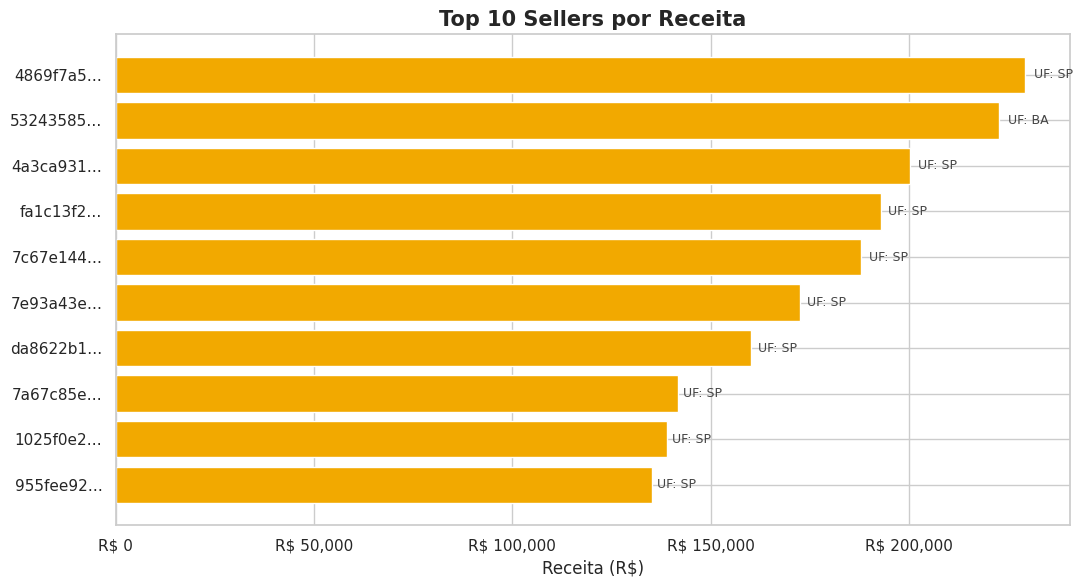

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(top_sellers["seller_id_curto"][::-1], top_sellers["receita"][::-1],
               color=PALETTE[5])
ax.set_xlabel("Receita (R$)")
ax.set_title("Top 10 Sellers por Receita")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))

for bar, uf in zip(bars, top_sellers["uf"][::-1]):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
            f"UF: {uf}", va="center", fontsize=9, color="#444444")

plt.tight_layout()
plt.show()

**Leitura executiva:** os produtos e sellers com maior receita são candidatos naturais a receberem
prioridade em campanhas, negociação de condições comerciais e garantia de estoque/capacidade logística,
por representarem uma parcela desproporcional do faturamento.